### **L1 regularization - figuring it out from scratch**

OK so I keep seeing L1 regularization pop up everywhere and I want to actually understand what it does and *why* it works, not just blindly apply it.

Plan for this notebook:
- make up a simple dataset (house prices, something concrete)
- remind myself what coefficients actually mean
- train a plain linear regression, look at what it gets wrong
- then throw L1 (Lasso) at it and see how the coefficients change

The real question I'm trying to answer: what problem does L1 solve that plain regression doesn't?

#### **1. setting up the problem**

Going with house prices - it's the most intuitive thing I can think of. Features like size, bedrooms, age, distance to city, garage, garden... stuff where  can actually reason about whether a coefficient makes sense or not. That matters later when I want to check if the model is learning garbage.

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

#### **2. making up the data**

Synthetic data so I know the ground truth - I define exactly which features matter and by how much, then I can check if the model recovers the right answer.

Key trick: I'm also throwing in some junk features (random noise, lucky numbers, paint color scores - total nonsense) and a couple of near-duplicates of real features. This is the kind of mess L1 is supposed to handle. If it works, the irrelevant ones should get zeroed out.

In [119]:
n_houses = 200

data = pd.DataFrame({
    "house_size_sqft": np.random.normal(1800, 400, n_houses),
    "num_bedrooms": np.random.randint(1, 6, n_houses),
    "num_bathrooms": np.random.randint(1, 4, n_houses),
    "age_of_house": np.random.randint(0, 50, n_houses),
    "distance_to_city_km": np.random.normal(12, 5, n_houses),
    "near_school": np.random.randint(0, 2, n_houses),
    "has_garden": np.random.randint(0, 2, n_houses),
    "has_garage": np.random.randint(0, 2, n_houses),
    "crime_rate_area": np.random.normal(5, 2, n_houses),
    "local_shops_nearby": np.random.randint(0, 10, n_houses),

    # Irrelevant features: random noise with no true relationship to price
    "owner_lucky_number": np.random.randint(1, 100, n_houses),
    "paint_color_score": np.random.normal(50, 10, n_houses),
    "random_noise_feature": np.random.normal(0, 1, n_houses),
})

# Redundant features: mostly copies of useful features, plus a little noise
data["house_size_sqft_duplicate"] = data["house_size_sqft"] + np.random.normal(0, 40, n_houses)
data["distance_to_city_km_duplicate"] = data["distance_to_city_km"] + np.random.normal(0, 0.8, n_houses)

# Hidden rule used to generate price.
# These are the true effects in our synthetic world.
true_weights = {
    "house_size_sqft": 120,
    "num_bedrooms": 8000,
    "num_bathrooms": 12000,
    "age_of_house": -1500,
    "distance_to_city_km": -3000,
    "near_school": 10000,
    "has_garden": 15000,
    "has_garage": 12000,
    "crime_rate_area": -5000,
    "local_shops_nearby": 2000,

    # These features should not matter in the true rule
    "owner_lucky_number": 0,
    "paint_color_score": 0,
    "random_noise_feature": 0,
    "house_size_sqft_duplicate": 0,
    "distance_to_city_km_duplicate": 0,
}

noise = np.random.normal(0, 20000, n_houses)

data["house_price"] = (
    data["house_size_sqft"] * true_weights["house_size_sqft"]
    + data["num_bedrooms"] * true_weights["num_bedrooms"]
    + data["num_bathrooms"] * true_weights["num_bathrooms"]
    + data["age_of_house"] * true_weights["age_of_house"]
    + data["distance_to_city_km"] * true_weights["distance_to_city_km"]
    + data["near_school"] * true_weights["near_school"]
    + data["has_garden"] * true_weights["has_garden"]
    + data["has_garage"] * true_weights["has_garage"]
    + data["crime_rate_area"] * true_weights["crime_rate_area"]
    + data["local_shops_nearby"] * true_weights["local_shops_nearby"]
    + data["owner_lucky_number"] * true_weights["owner_lucky_number"]
    + data["paint_color_score"] * true_weights["paint_color_score"]
    + data["random_noise_feature"] * true_weights["random_noise_feature"]
    + data["house_size_sqft_duplicate"] * true_weights["house_size_sqft_duplicate"]
    + data["distance_to_city_km_duplicate"] * true_weights["distance_to_city_km_duplicate"]
    + noise
)

data.head()

,house_size_sqft,num_bedrooms,num_bathrooms,age_of_house,distance_to_city_km,near_school,has_garden,has_garage,crime_rate_area,local_shops_nearby,owner_lucky_number,paint_color_score,random_noise_feature,house_size_sqft_duplicate,distance_to_city_km_duplicate,house_price
0,1998.685661,2,1,39,13.951266,0,1,1,6.795777,8,5,61.682177,-0.526078,1926.284365,14.712835,165910.839533
1,1744.694280,2,3,31,11.575456,0,0,0,4.586866,4,84,41.370947,-0.014020,1717.176925,12.456380,169695.133423
2,2059.075415,1,1,33,13.186622,1,0,0,3.578256,0,65,26.973030,0.101644,2118.037657,12.858654,186968.470202
3,2409.211943,1,1,27,13.367887,1,1,1,3.661758,9,30,45.550542,-1.131026,2395.131420,12.770225,252840.250684
4,1706.338650,1,3,30,8.379991,0,0,1,5.148412,6,21,41.251796,-1.762832,1741.770776,9.296302,220631.600315


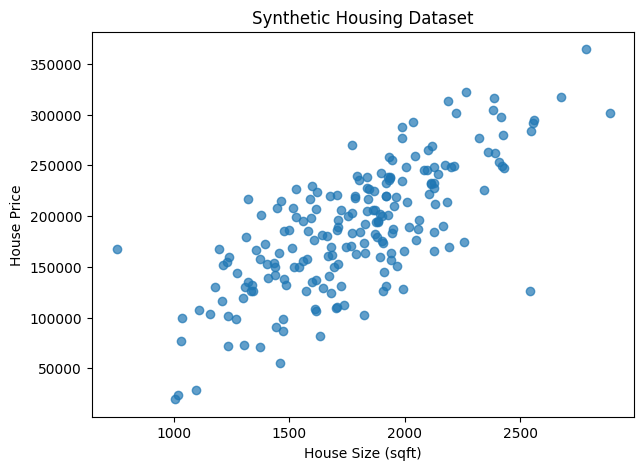

In [120]:
plt.figure(figsize=(7, 5))
plt.scatter(data["house_size_sqft"], data["house_price"], alpha=0.7)
plt.xlabel("House Size (sqft)")
plt.ylabel("House Price")
plt.title("Synthetic Housing Dataset")
plt.show()

#### **3. quick refresher - what's a coefficient anyway**

The model learns: `price = b0 + b1*x1 + b2*x2 + ...`

Each coefficient (b1, b2, ...) is just how much that feature pushes the predicted price up or down. 
* Positive = more of that feature → higher price. 
* Negative = higher value → lower price. 
* Bigger magnitude = more influence.

The whole point of L1: it can push some of these coefficients *exactly* to zero, which effectively kills that feature. That's the key insight I want to verify.

#### **4. prep the data**
Standard stuff - split into features + target, then standardize. The standardization actually matters here because regularization penalizes coefficient size, so if features are on wildly different scales the penalty hits them unevenly. Need everything comparable.

In [121]:
X = data.drop(columns=["house_price"])
y = data["house_price"]

feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Training shape: (160, 15)
Test shape: (40, 15)


#### **5. baseline - just plain linear regression**

First, train a normal regression with no penalty at all. Need this as a reference point - can't evaluate L1 if I don't know what 'no regularization' looks like.

The thing about plain OLS[Ordinary Least Squares] is it'll happily use *every* feature, even noisy ones. It doesn't try to be sparse. Let's see if that's actually what happens.

In [122]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_coefficients = pd.Series(linear_model.coef_, index=feature_names)

y_train_pred_linear = linear_model.predict(X_train_scaled)
y_test_pred_linear = linear_model.predict(X_test_scaled)

linear_train_rmse = mean_squared_error(y_train, y_train_pred_linear) ** 0.5
linear_test_rmse = mean_squared_error(y_test, y_test_pred_linear) ** 0.5
linear_train_r2 = r2_score(y_train, y_train_pred_linear)
linear_test_r2 = r2_score(y_test, y_test_pred_linear)

print("Normal Linear Regression Coefficients:\n")
print(linear_coefficients.sort_values(key=abs, ascending=False))

print(f"\nTrain RMSE: {linear_train_rmse:,.2f}")
print(f"Test RMSE:  {linear_test_rmse:,.2f}")
print(f"Train R^2:  {linear_train_r2:.3f}")
print(f"Test R^2:   {linear_test_r2:.3f}")

Normal Linear Regression Coefficients:

house_size_sqft                  28345.662693
house_size_sqft_duplicate        18487.794475
distance_to_city_km_duplicate   -17326.827008
age_of_house                    -17092.280330
num_bedrooms                     16586.920508
num_bathrooms                    11726.042217
crime_rate_area                 -10298.935418
has_garage                        7781.428764
has_garden                        6823.318205
near_school                       5224.989392
local_shops_nearby                4571.674860
paint_color_score                  727.450633
random_noise_feature              -602.385843
owner_lucky_number                -586.581103
distance_to_city_km                165.472921
dtype: float64

Train RMSE: 18,113.57
Test RMSE:  23,935.42
Train R^2:  0.917
Test R^2:   0.799


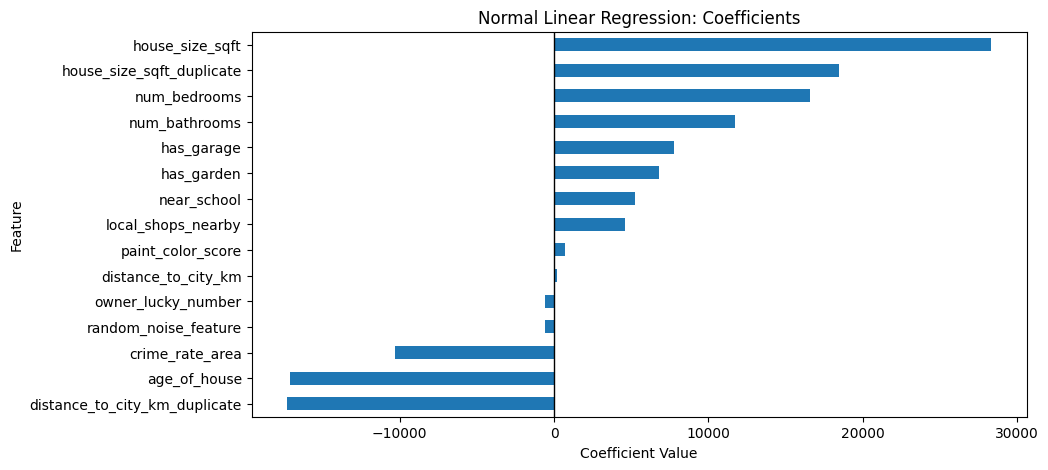

In [123]:
plt.figure(figsize=(10, 5))
linear_coefficients.sort_values().plot(kind="barh")
plt.axvline(0, color="black", linewidth=1)
plt.title("Normal Linear Regression: Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

#### **reading this plot**


* Bars to the right = that feature pushes price up. 
* Bars to the left = pushes it down. Longer bar = bigger effect.

And yeah - exactly as expected, virtually every feature got *some* nonzero coefficient. Even the pure-garbage ones like `owner_lucky_number`. The model just uses everything it can grab, no filtering at all.

That's the whole point - plain regression doesn't do feature selection. It just fits.

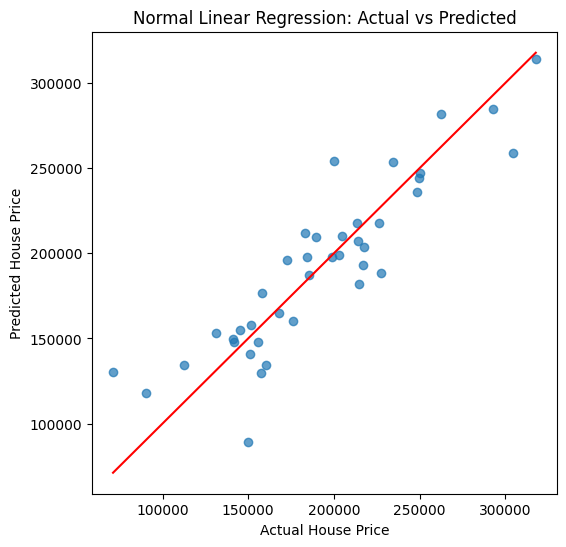

In [124]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_linear, alpha=0.7)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Normal Linear Regression: Actual vs Predicted")

low = min(y_test.min(), y_test_pred_linear.min())
high = max(y_test.max(), y_test_pred_linear.max())
plt.plot([low, high], [low, high], color="red")
plt.show()

#### **6. so what's wrong with that?**

Nothing is *wrong* with OLS per se. It does what it's supposed to. But it won't simplify anything  - it keeps every feature, including noise.

If I want a model that actually *picks* which features matter and ignores the rest, I need something extra. That's where L1 comes in. A coefficient going to exactly zero means that feature is gone from the model. Not just small - gone.

#### **7. L1 / Lasso - let's try it**

OK so normal regression just minimizes prediction error - that's it. The loss is:

`Loss = Σ(actual_price - predicted_price)²`

The model will do whatever it takes to make that number small, even if it means giving every feature some nonzero weight. It doesn't care if a feature is garbage - if using it reduces the error by even a tiny amount, it'll use it.

L1 changes the game by adding a penalty:

`Loss = Σ(actual_price - predicted_price)² + λ * Σ|w_i|`

Let me break down that penalty part - λ * Σ|w_i|:

* `w_i` are the coefficients the model learns - one per feature
* `|w_i|` is the absolute value, so we just care about magnitude, not sign
* `Σ|w_i|` = add them all up. If I have weights [300, -150, 0, 80, -20], the sum is 300+150+0+80+20 = 550. Basically a measure of "how much total weight is the model using"
* `λ` is a dial I choose. λ=0 means ignore the penalty entirely (back to normal regression). λ=huge means crush everything toward zero
* so `λ * Σ|w_i|` gets added to the prediction error, which means keeping any coefficient alive has a cost
The optimizer now thinks: "setting w₅ = -20 helps predictions a tiny bit, but it adds 20 to my penalty... is that worth it?" If λ is big enough, the answer is no, and w₅ gets pushed to exactly 0.

The key intuition for why L1 kills features entirely instead of just shrinking them: the absolute value penalty has a constant gradient - it pushes toward zero at the same rate no matter how small the coefficient already is. So weak features that barely help get shoved all the way to 0. The cost of keeping them alive outweighs the benefit.

That's the magic - not just shrinkage, actual selection. Zero coefficient = feature deleted from the model.

In sklearn this is `Lasso`. The knob is `alpha` (their name for λ) - bigger alpha = stronger penalty = more zeros.



In [125]:
lasso_model = Lasso(alpha=2000)
lasso_model.fit(X_train_scaled, y_train)

lasso_coefficients = pd.Series(lasso_model.coef_, index=feature_names)

y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_train_rmse = mean_squared_error(y_train, y_train_pred_lasso) ** 0.5
lasso_test_rmse = mean_squared_error(y_test, y_test_pred_lasso) ** 0.5
lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)

num_zero_lasso = int((lasso_coefficients == 0).sum())
num_nonzero_lasso = int((lasso_coefficients != 0).sum())

print("L1 / Lasso Coefficients:\n")
print(lasso_coefficients.sort_values(key=abs, ascending=False))

print(f"\nNumber of coefficients pushed to exactly 0: {num_zero_lasso}")
print(f"Number of active features left: {num_nonzero_lasso}")

print(f"\nTrain RMSE: {lasso_train_rmse:,.2f}")
print(f"Test RMSE:  {lasso_test_rmse:,.2f}")
print(f"Train R^2:  {lasso_train_r2:.3f}")
print(f"Test R^2:   {lasso_test_r2:.3f}")

L1 / Lasso Coefficients:

house_size_sqft                  25713.003923
house_size_sqft_duplicate        18966.813967
age_of_house                    -16501.297669
distance_to_city_km_duplicate   -14949.887742
num_bedrooms                     14243.817110
num_bathrooms                     9393.969289
crime_rate_area                  -8152.403438
has_garage                        5933.049331
has_garden                        4445.588073
near_school                       3121.436679
local_shops_nearby                2272.439437
distance_to_city_km                 -0.000000
owner_lucky_number                   0.000000
paint_color_score                    0.000000
random_noise_feature                -0.000000
dtype: float64

Number of coefficients pushed to exactly 0: 4
Number of active features left: 11

Train RMSE: 19,254.61
Test RMSE:  23,009.11
Train R^2:  0.906
Test R^2:   0.815


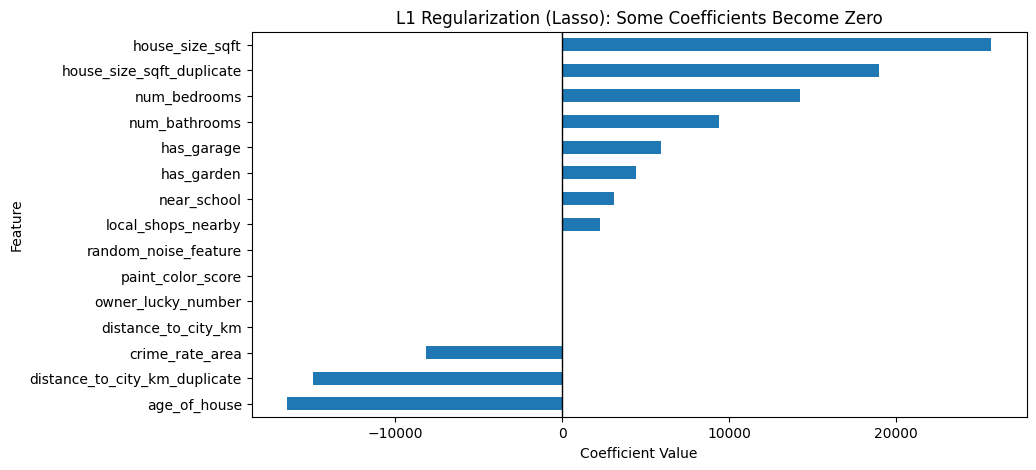

In [126]:
plt.figure(figsize=(10, 5))
lasso_coefficients.sort_values().plot(kind="barh")
plt.axvline(0, color="black", linewidth=1)
plt.title("L1 Regularization (Lasso): Some Coefficients Become Zero")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [127]:
comparison_df = pd.DataFrame({
    "Linear Regression": linear_coefficients,
    "L1 / Lasso": lasso_coefficients,
})

comparison_df

,Linear Regression,L1 / Lasso
house_size_sqft,28345.662693,25713.003923
num_bedrooms,16586.920508,14243.817110
num_bathrooms,11726.042217,9393.969289
age_of_house,-17092.280330,-16501.297669
distance_to_city_km,165.472921,-0.000000
near_school,5224.989392,3121.436679
has_garden,6823.318205,4445.588073
has_garage,7781.428764,5933.049331
crime_rate_area,-10298.935418,-8152.403438
local_shops_nearby,4571.674860,2272.439437


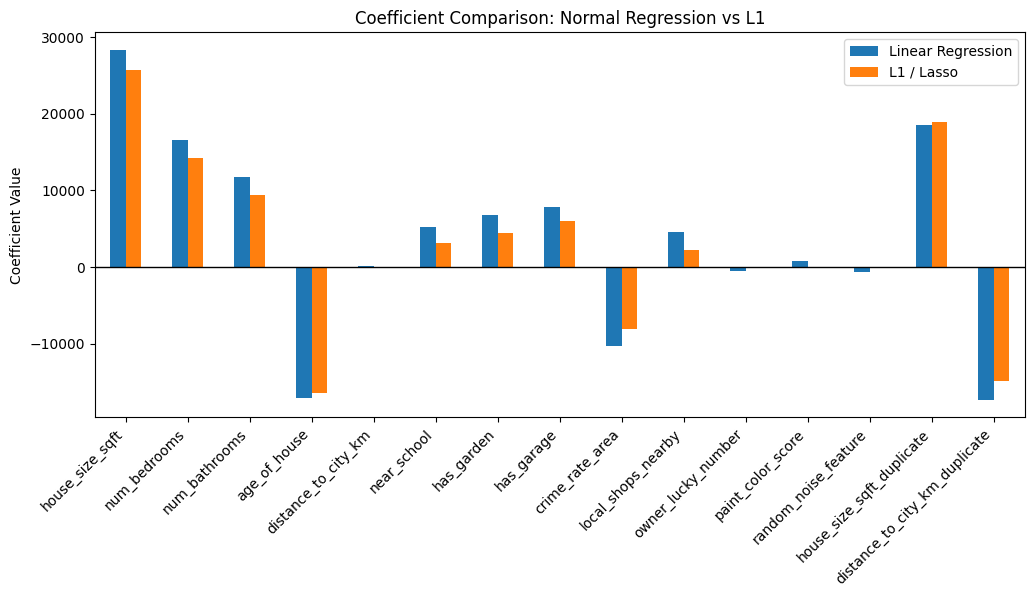

In [128]:
comparison_df.plot(kind="bar", figsize=(12, 5))
plt.axhline(0, color="black", linewidth=1)
plt.title("Coefficient Comparison: Normal Regression vs L1")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.show()

#### **8. looking at the result**

With `alpha=2000` - interesting. Coefficients shrank compared to OLS, but none of them actually hit zero. So shrinkage happened, but feature selection didn't kick in yet.

This makes sense - the penalty isn't strong enough to kill anything off completely. We're in a halfway state: things are getting smaller but nothing's been eliminated.

The obvious next thing to try: crank up alpha more and see at what point features actually start disappearing. One alpha value tells  almost nothing - need to sweep.

#### **9. alpha sweep**

Let's loop over a range of alphas and track: train RMSE, test RMSE, and how many features are still alive (nonzero coeff). Train vs test tells me if the model is getting too aggressive; the active feature count tells me if L1 is actually doing anything.

In [129]:
alpha_values = [0, 100, 500, 1000, 2000, 4000, 8000, 12000, 20000]

alpha_results = []

for alpha in alpha_values:
    if alpha == 0:
        train_rmse = linear_train_rmse
        test_rmse = linear_test_rmse
        nonzero_count = int((linear_coefficients != 0).sum())
        zero_count = int((linear_coefficients == 0).sum())
    else:
        model = Lasso(alpha=alpha)
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
        test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
        nonzero_count = int((model.coef_ != 0).sum())
        zero_count = int((model.coef_ == 0).sum())

    alpha_results.append({
        "alpha": alpha,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "active_features": nonzero_count,
        "zero_features": zero_count,
    })

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df

,alpha,train_rmse,test_rmse,active_features,zero_features
0,0,18113.565441,23935.419579,15,0
1,100,18117.231705,23873.042989,14,1
2,500,18198.650171,23673.832241,13,2
3,1000,18424.425411,23375.218368,12,3
4,2000,19254.610303,23009.108495,11,4
5,4000,22244.507724,23752.852256,10,5
6,8000,29255.275806,27583.178181,7,8
7,12000,34630.902744,30676.020993,5,10
8,20000,43692.309454,36569.934214,3,12


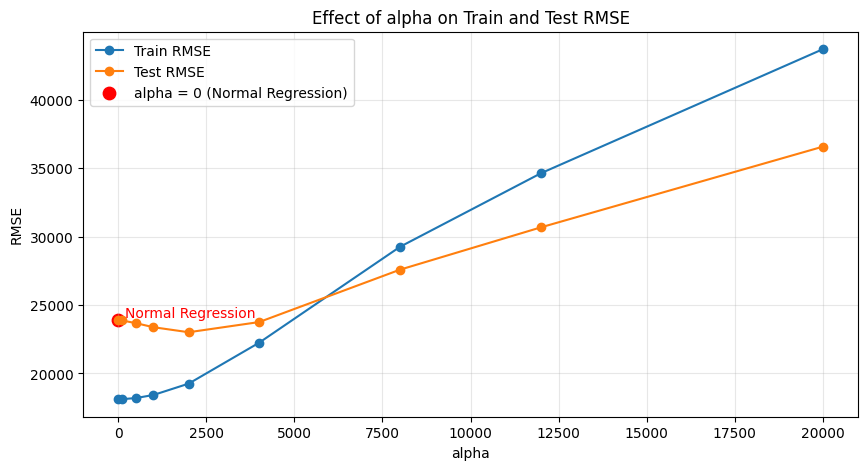

In [130]:
plt.figure(figsize=(10, 5))
plt.plot(alpha_results_df["alpha"], alpha_results_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(alpha_results_df["alpha"], alpha_results_df["test_rmse"], marker="o", label="Test RMSE")
plt.scatter(alpha_results_df.loc[0, "alpha"], alpha_results_df.loc[0, "test_rmse"], color="red", s=80, label="alpha = 0 (Normal Regression)")
plt.text(alpha_results_df.loc[0, "alpha"] + 200, alpha_results_df.loc[0, "test_rmse"] + 150, "Normal Regression", color="red")
plt.xlabel("alpha")
plt.ylabel("RMSE")
plt.title("Effect of alpha on Train and Test RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

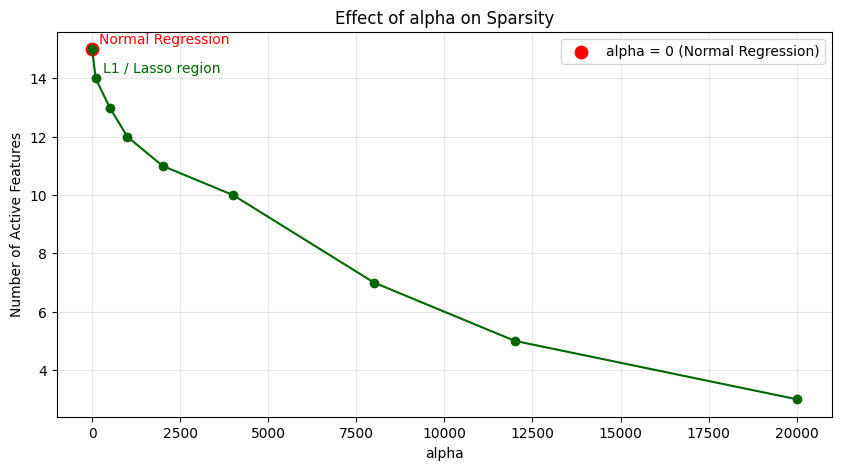

In [131]:
plt.figure(figsize=(10, 5))
plt.plot(alpha_results_df["alpha"], alpha_results_df["active_features"], marker="o", color="darkgreen")
plt.scatter(alpha_results_df.loc[0, "alpha"], alpha_results_df.loc[0, "active_features"], color="red", s=80, label="alpha = 0 (Normal Regression)")
plt.text(alpha_results_df.loc[0, "alpha"] + 200, alpha_results_df.loc[0, "active_features"] + 0.2, "Normal Regression", color="red")
plt.text(alpha_results_df.loc[1, "alpha"] + 200, alpha_results_df.loc[1, "active_features"] + 0.2, "L1 / Lasso region", color="darkgreen")
plt.xlabel("alpha")
plt.ylabel("Number of Active Features")
plt.title("Effect of alpha on Sparsity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### **reading the sweep**

RMSE plot: does making it sparser actually hurt predictions? If RMSE barely moves as alpha grows, then those features it dropped were harmless - we're getting simplicity for free.

Active features plot: when does the line start dropping? That's the moment L1 kicks in and actually starts killing features. The question is just: how far can we push before we lose accuracy.

#### **10. now L2 / Ridge for comparison**

L2 penalty is `λ * Σ(w_i²)` - squares instead of absolute values. The fundamental difference: L2 shrinks everything toward zero but almost never actually reaches it. So it smooths the model out without dropping features.

I want to see this concretely - same data, same setup, but Ridge instead of Lasso.

In [132]:
ridge_model = Ridge(alpha=2000)
ridge_model.fit(X_train_scaled, y_train)

ridge_coefficients = pd.Series(ridge_model.coef_, index=feature_names)

y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_train_rmse = mean_squared_error(y_train, y_train_pred_ridge) ** 0.5
ridge_test_rmse = mean_squared_error(y_test, y_test_pred_ridge) ** 0.5
ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

num_zero_ridge = int((ridge_coefficients == 0).sum())
num_nonzero_ridge = int((ridge_coefficients != 0).sum())

print("L2 / Ridge Coefficients:\n")
print(ridge_coefficients.sort_values(key=abs, ascending=False))

print(f"\nNumber of coefficients pushed to exactly 0: {num_zero_ridge}")
print(f"Number of active features left: {num_nonzero_ridge}")

print(f"\nTrain RMSE: {ridge_train_rmse:,.2f}")
print(f"Test RMSE:  {ridge_test_rmse:,.2f}")
print(f"Train R^2:  {ridge_train_r2:.3f}")
print(f"Test R^2:   {ridge_test_r2:.3f}")

L2 / Ridge Coefficients:

house_size_sqft_duplicate        3222.093380
house_size_sqft                  3207.654142
age_of_house                    -1752.950194
num_bedrooms                     1412.993713
distance_to_city_km_duplicate   -1349.176291
distance_to_city_km             -1261.945661
num_bathrooms                     891.330088
has_garage                        771.580878
near_school                       669.212861
random_noise_feature             -610.673967
has_garden                        394.696430
owner_lucky_number                366.017457
crime_rate_area                  -268.717670
local_shops_nearby                -76.561966
paint_color_score                  64.137785
dtype: float64

Number of coefficients pushed to exactly 0: 0
Number of active features left: 15

Train RMSE: 55,546.72
Test RMSE:  48,006.06
Train R^2:  0.217
Test R^2:   0.193


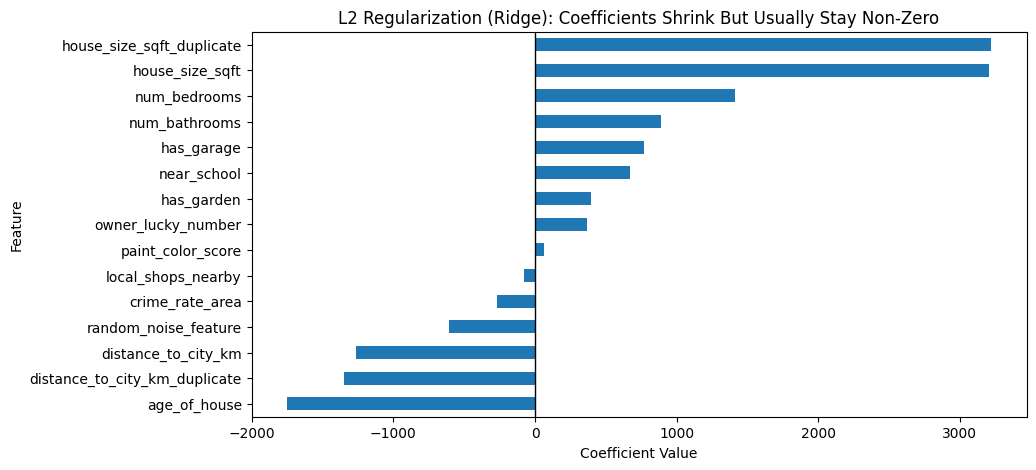

In [133]:
plt.figure(figsize=(10, 5))
ridge_coefficients.sort_values().plot(kind="barh")
plt.axvline(0, color="black", linewidth=1)
plt.title("L2 Regularization (Ridge): Coefficients Shrink But Usually Stay Non-Zero")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

#### **11. alpha sweep for L2 too**

Same drill - sweep over alphas, track RMSE and active features. But I expect the sparsity plot to stay flat (all features active, always). That's the whole point of Ridge - it shrinks, it doesn't select.

In [134]:
ridge_alpha_values = [0, 100, 500, 1000, 2000, 4000, 8000, 12000, 20000]

ridge_alpha_results = []

for alpha in ridge_alpha_values:
    if alpha == 0:
        train_rmse = linear_train_rmse
        test_rmse = linear_test_rmse
        nonzero_count = int((linear_coefficients != 0).sum())
        zero_count = int((linear_coefficients == 0).sum())
    else:
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
        test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
        nonzero_count = int((model.coef_ != 0).sum())
        zero_count = int((model.coef_ == 0).sum())

    ridge_alpha_results.append({
        "alpha": alpha,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "active_features": nonzero_count,
        "zero_features": zero_count,
    })

ridge_alpha_results_df = pd.DataFrame(ridge_alpha_results)
ridge_alpha_results_df

,alpha,train_rmse,test_rmse,active_features,zero_features
0,0,18113.565441,23935.419579,15,0
1,100,24709.020164,26459.903887,15,0
2,500,42616.138406,38311.130359,15,0
3,1000,50146.931088,43888.204941,15,0
4,2000,55546.723630,48006.061927,15,0
5,4000,58878.788576,50587.169939,15,0
6,8000,60748.186677,52047.141379,15,0
7,12000,61405.633050,52562.506811,15,0
8,20000,61944.777362,52985.855686,15,0


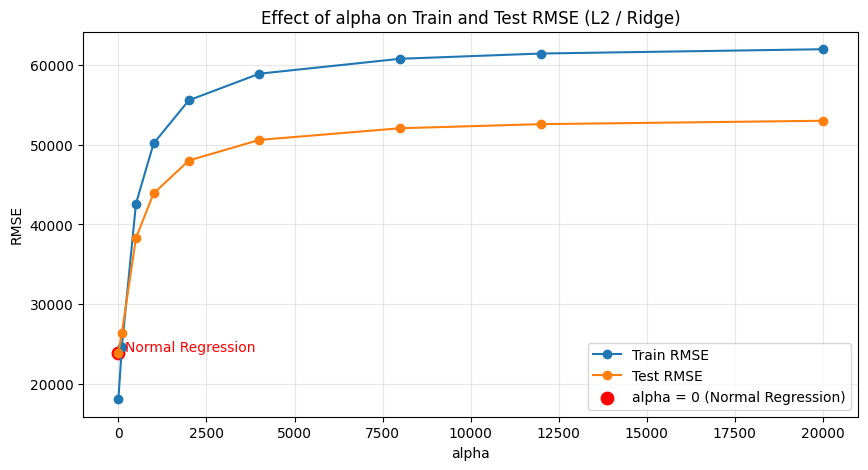

In [135]:
plt.figure(figsize=(10, 5))
plt.plot(ridge_alpha_results_df["alpha"], ridge_alpha_results_df["train_rmse"], marker="o", label="Train RMSE")
plt.plot(ridge_alpha_results_df["alpha"], ridge_alpha_results_df["test_rmse"], marker="o", label="Test RMSE")
plt.scatter(ridge_alpha_results_df.loc[0, "alpha"], ridge_alpha_results_df.loc[0, "test_rmse"], color="red", s=80, label="alpha = 0 (Normal Regression)")
plt.text(ridge_alpha_results_df.loc[0, "alpha"] + 200, ridge_alpha_results_df.loc[0, "test_rmse"] + 150, "Normal Regression", color="red")
plt.xlabel("alpha")
plt.ylabel("RMSE")
plt.title("Effect of alpha on Train and Test RMSE (L2 / Ridge)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

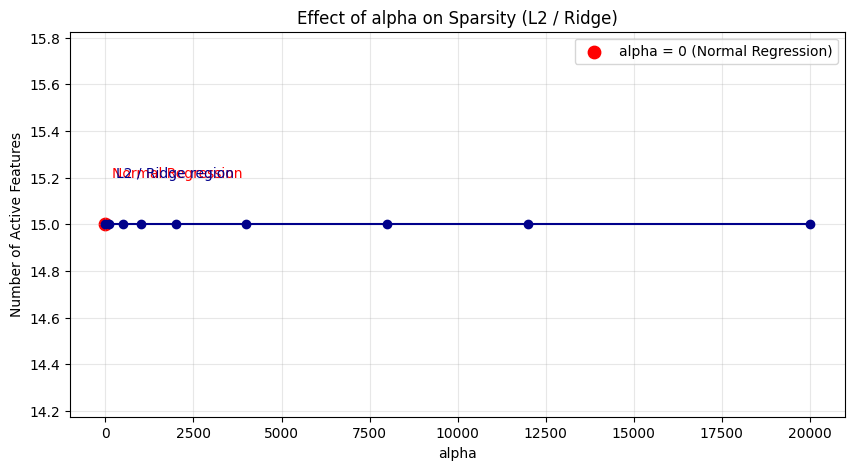

In [136]:
plt.figure(figsize=(10, 5))
plt.plot(ridge_alpha_results_df["alpha"], ridge_alpha_results_df["active_features"], marker="o", color="darkblue")
plt.scatter(ridge_alpha_results_df.loc[0, "alpha"], ridge_alpha_results_df.loc[0, "active_features"], color="red", s=80, label="alpha = 0 (Normal Regression)")
plt.text(ridge_alpha_results_df.loc[0, "alpha"] + 200, ridge_alpha_results_df.loc[0, "active_features"] + 0.2, "Normal Regression", color="red")
plt.text(ridge_alpha_results_df.loc[1, "alpha"] + 200, ridge_alpha_results_df.loc[1, "active_features"] + 0.2, "L2 / Ridge region", color="darkblue")
plt.xlabel("alpha")
plt.ylabel("Number of Active Features")
plt.title("Effect of alpha on Sparsity (L2 / Ridge)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### **L2 sweep results**

Yep - the sparsity curve for Ridge is basically flat. All 15 features stay active no matter how big alpha gets. The coefficients get smaller and smaller but none of them actually die. That's the L1 vs L2 difference in one picture.

In [137]:
comparison_df_all = pd.DataFrame({
    "Normal Regression": linear_coefficients,
    "L1 / Lasso": lasso_coefficients,
    "L2 / Ridge": ridge_coefficients,
})

comparison_df_all

,Normal Regression,L1 / Lasso,L2 / Ridge
house_size_sqft,28345.662693,25713.003923,3207.654142
num_bedrooms,16586.920508,14243.817110,1412.993713
num_bathrooms,11726.042217,9393.969289,891.330088
age_of_house,-17092.280330,-16501.297669,-1752.950194
distance_to_city_km,165.472921,-0.000000,-1261.945661
near_school,5224.989392,3121.436679,669.212861
has_garden,6823.318205,4445.588073,394.696430
has_garage,7781.428764,5933.049331,771.580878
crime_rate_area,-10298.935418,-8152.403438,-268.717670
local_shops_nearby,4571.674860,2272.439437,-76.561966


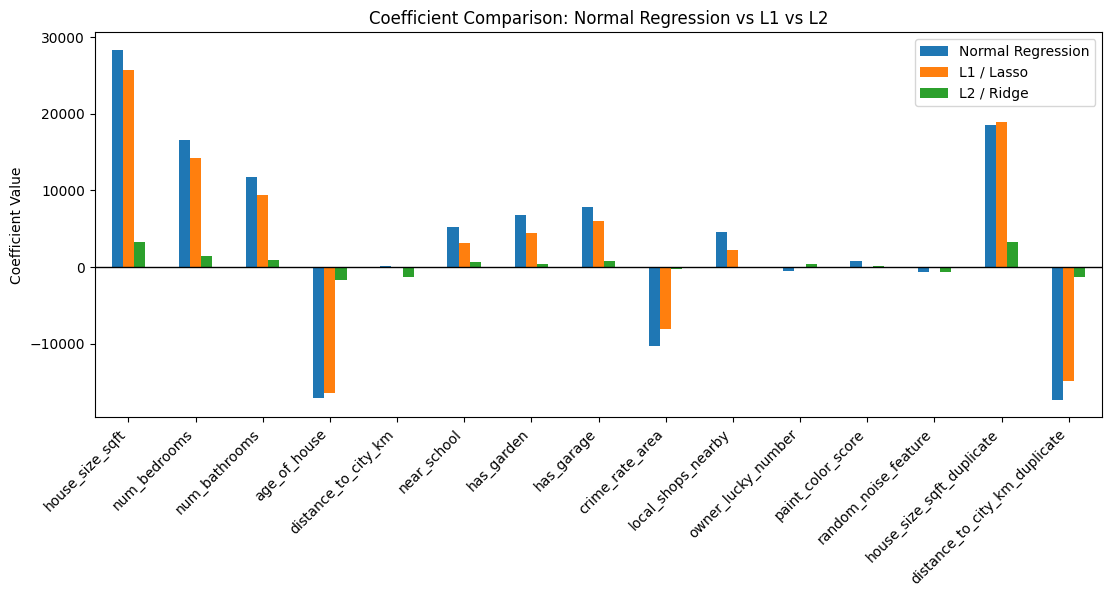

In [138]:
comparison_df_all.plot(kind="bar", figsize=(13, 5))
plt.axhline(0, color="black", linewidth=1)
plt.title("Coefficient Comparison: Normal Regression vs L1 vs L2")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.show()

#### the comparison

Look at the coefficients side by side. Regression: big and noisy. Lasso: some of them gone completely. Ridge: everything's still there, just squished down.

Mental shorthand: **L1 chooses, L2 smooths.**

#### **12. takeaways**

- Plain regression: uses everything, no filtering.
- L1: can zero out useless features. Actual feature selection.
- L2: shrinks everything toward zero but keeps all features alive. Smoothing, not selecting.

Bottom line - L1 when I want sparsity, L2 when I want stability. And always compare against the unregularized baseline because adding a penalty isn't free - it's a tradeoff.